In [1]:
from dataclasses import asdict
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
clustering_run = ds.pipeline.open(label="docs_default")
graph = clustering_run["connectivity_map"]
umap = clustering_run["umap"]
umap_values = np.asarray(ds.load_artifact(umap)["values"][:])

In [2]:
leiden_refs = {
    0.3: ds.run_leiden_clustering(graph, resolution=0.3),
    0.5: clustering_run["leiden_0.5"],
    0.8: ds.run_leiden_clustering(graph, resolution=0.8),
}
leiden_values = {
    resolution: np.asarray(ds.load_artifact(ref)["values"][:])
    for resolution, ref in leiden_refs.items()
}

pd.DataFrame(
    {
        resolution: pd.Series(values).value_counts()
        for resolution, values in leiden_values.items()
    }
).fillna(0).astype(int)

,0.3,0.5,0.8
1,722,694,354
2,237,28,368
3,1264,237,237
4,683,1004,708
5,285,317,553
6,317,539,462
7,142,142,287
8,263,263,356
9,15,378,144
10,12,311,151


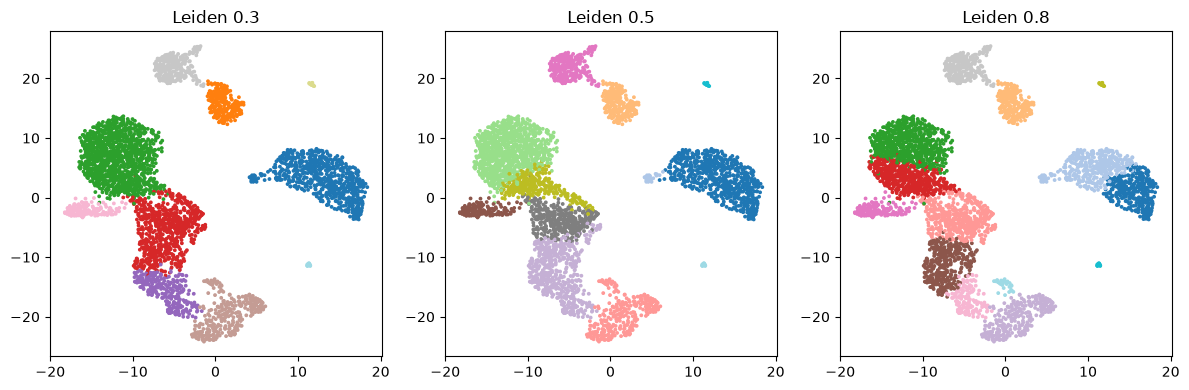

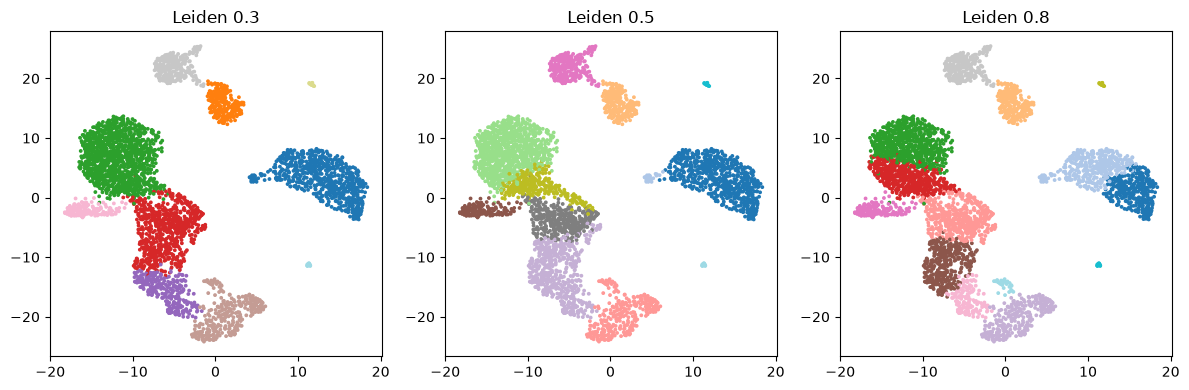

In [3]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, resolution in zip(axes, leiden_values, strict=True):
    axis.scatter(
        umap_values[:, 0],
        umap_values[:, 1],
        c=leiden_values[resolution],
        s=3,
        cmap="tab20",
    )
    axis.set_title(f"Leiden {resolution}")
figure.tight_layout()
figure

In [4]:
agreement = []
for first, second in combinations(leiden_values, 2):
    agreement.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": adjusted_rand_score(
                leiden_values[first],
                leiden_values[second],
            ),
            "NMI": normalized_mutual_info_score(
                leiden_values[first],
                leiden_values[second],
            ),
        }
    )
pd.DataFrame(agreement)

,comparison,ARI,NMI
0,0.3 vs 0.5,0.770245,0.878099
1,0.3 vs 0.8,0.647471,0.852723
2,0.5 vs 0.8,0.674633,0.847042


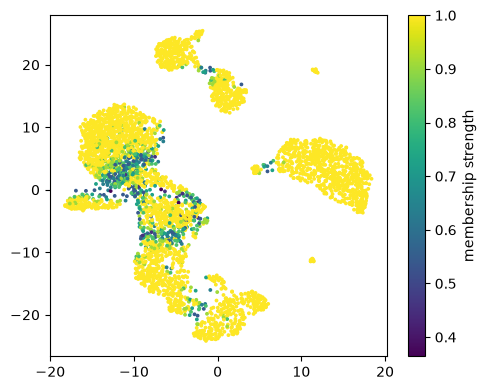

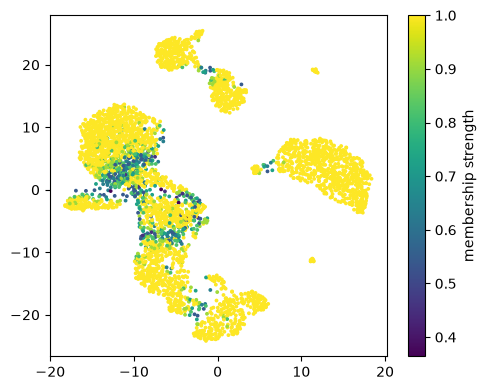

In [5]:
chosen = leiden_refs[0.5]
chosen_values = leiden_values[0.5]
membership = ds.calc_membership_strength(chosen, graph)
membership_values = np.asarray(ds.load_artifact(membership)["values"][:])

figure, axis = plt.subplots(figsize=(5, 4))
points = axis.scatter(
    umap_values[:, 0],
    umap_values[:, 1],
    c=membership_values,
    s=3,
)
figure.colorbar(points, ax=axis, label="membership strength")
figure.tight_layout()
figure

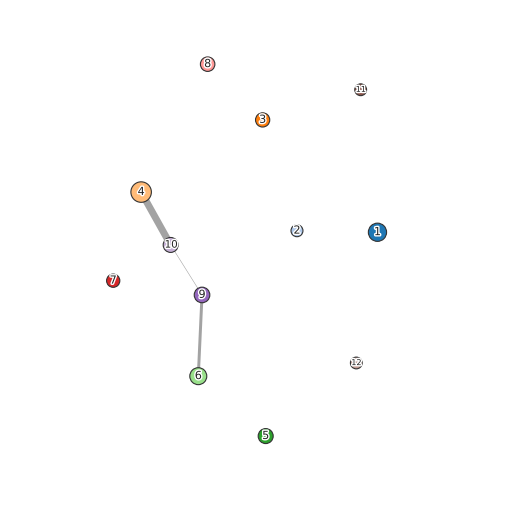

In [6]:
ds.plots.cluster_connectivity(
    graph=graph,
    groups=chosen,
    layout=umap,
)

In [7]:
paris_auto = ds.run_paris_clustering(graph)
paris_result = ds.load_paris_clustering(paris_auto)
pd.DataFrame([asdict(item) for item in paris_result.diagnostics])[
    ["label", "size", "persistence", "decision_margin", "forced"]
]

,label,size,persistence,decision_margin,forced
0,1,337,79.705419,0.065040,False
1,2,385,89.092184,0.055471,False
2,3,257,132.482178,0.418605,False
3,4,1269,315.001767,0.067197,False
4,5,317,147.956538,0.164591,False
5,6,558,77.990342,NaN,False
6,7,137,97.023762,0.602801,False
7,8,243,100.905112,0.219834,False
8,9,410,128.162219,0.131857,False
9,10,15,NaN,NaN,True


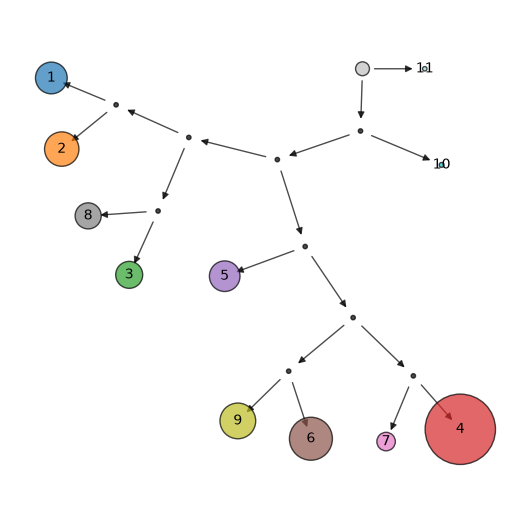

In [8]:
ds.plots.cluster_tree(graph=graph, clusters=paris_auto)

In [9]:
paris_fixed = ds.run_paris_clustering(
    graph,
    n_clusters=paris_result.n_clusters,
)
paris_auto_values = np.asarray(ds.load_artifact(paris_auto)["labels"][:])
paris_fixed_values = np.asarray(ds.load_artifact(paris_fixed)["labels"][:])
pd.Series(
    {
        "auto vs fixed ARI": adjusted_rand_score(
            paris_auto_values,
            paris_fixed_values,
        ),
        "Leiden vs Paris ARI": adjusted_rand_score(
            chosen_values,
            paris_auto_values,
        ),
    }
)

auto vs fixed ARI      0.731157
Leiden vs Paris ARI    0.736240
dtype: float64

In [10]:
markers = ds.run_marker_search(
    chosen,
    features=clustering_run["feature_universe"],
)
sizes = pd.Series(chosen_values).value_counts()
largest = sizes.index[0]
smallest = sizes.index[-1]

largest_markers = ds.get_markers(marker=markers, group_id=largest)
smallest_markers = ds.get_markers(marker=markers, group_id=smallest)

In [11]:
largest_markers[
    ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.41057,0.60208,2.122675e-83,3.727239e-81
1,FHIT,0.34388,0.75649,1.297768e-216,1.554448e-213
2,TSHZ2,0.31510,0.62291,4.188060e-84,7.471232e-82
3,CMTM8,0.31237,0.61065,2.354141e-65,2.892058e-63
4,EPHX2,0.31103,0.64836,3.218353e-101,7.709795e-99
5,LRRN3,0.30605,0.72201,1.099399e-191,9.703067e-189
6,CHRM3-AS2,0.30605,0.64164,3.369847e-97,7.435389e-95
7,NOG,0.30290,0.61092,1.214071e-91,2.482776e-89
8,MAN1C1,0.30181,0.60891,1.353549e-59,1.363223e-57
9,GSTM3,0.30174,0.60525,3.537595e-62,3.994743e-60


In [12]:
smallest_markers[
    ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,F13A1,0.81787,0.99998,2.737010e-45,4.477748e-43
1,ACRBP,0.80562,0.95774,2.061862e-132,6.286431e-130
2,PTGS1,0.79792,0.99998,2.044860e-73,5.042684e-71
3,PRKAR2B,0.79786,1.00000,2.000594e-184,1.016605e-181
4,AP003068.2,0.79489,0.95765,1.075183e-118,3.004959e-116
5,TST,0.79442,0.95476,2.582438e-41,4.124276e-39
6,CD9,0.79128,0.99992,8.068113e-78,2.049912e-75
7,HIST1H3H,0.78964,0.95730,1.836591e-99,5.007773e-97
8,CLU,0.78698,1.00000,2.078877e-194,1.106689e-191
9,HIST1H2BJ,0.78389,0.87170,5.732431e-54,9.808892e-52
